In [1]:
import os
from dotenv import load_dotenv
import xarray as xr

import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt

import analysis_utils
import isku_utils

import importlib

importlib.reload(analysis_utils)
importlib.reload(isku_utils)

/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<module 'isku_utils' from '/home/emily_zuetell/projects/poreallas/analysis/isku_utils.py'>

In [2]:
load_dotenv()
DATA_DIR = os.environ["DATA_DIR"]
EFFECTS_URI = os.environ["POREALLAS_EFFECTS_URI"]
IMPACT_REGION_POLYGONS = os.environ["POREALLAS_REGIONS_POLYGONS_URI"]
SOCIOECONOMICS_URI = os.environ["POREALLAS_SOCIOECONOMICS_URI"]

# Climate Data
TAS_FORECAST_URI = os.environ["POREALLAS_TAS_FORECAST_URI"]
ERA5_URI = os.environ["POREALLAS_ERA5_URI"]
TAS_FORECAST_RAW = os.environ["POREALLAS_TAS_FORECAST_RAW_URI"]

In [3]:
# Projection Effects
effect = xr.open_datatree(os.path.join(DATA_DIR, EFFECTS_URI), consolidated=False)
baseline_period = analysis_utils.get_baseline_period(effect, years=30)
# Impact Regions
_polygons = (
    gpd.read_parquet(os.path.join(DATA_DIR, IMPACT_REGION_POLYGONS))
    .rename(columns={"hierid": "region"})
    .set_index("region")
    .set_crs(epsg=4326)  # Assuming the data is WGS-82.
)

# Socioeconomics
socioeconomics = xr.open_zarr(os.path.join(DATA_DIR, SOCIOECONOMICS_URI))
socioeconomics = socioeconomics.sel(year=2026)[
    ["pop0to4", "pop5to64", "pop65plus", "pop", "gdppc", "iso3"]
]

In [4]:
### TEST DATA ###
# IR Climate Data
forecast = xr.open_zarr(os.path.join(DATA_DIR, TAS_FORECAST_URI)) - 273.15
# Gridded to Impact Region
forecast_ir = isku_utils.grid_to_ir(forecast, savefile=None)

era5 = (
    xr.open_zarr(os.path.join(DATA_DIR, ERA5_URI)).sel(
        time=slice("1996-01-01", "2025-12-31")
    )
    - 273.15
)
era5_ir = isku_utils.grid_to_ir(era5, savefile=None)
era5_ir = era5_ir.assign_coords(month=era5_ir["time"].dt.month)
# Intermediate Betas/MMT from Project.Py
betas_mmt = xr.open_zarr(os.path.join(DATA_DIR, "2608_beta_qdm_gamma_sampled.zarr"))

/home/emily_zuetell/projects/poreallas/analysis/isku_utils.py:29: RuntimeWarning: Failed to open Zarr store with consolidated metadata, but successfully read with non-consolidated metadata. This is typically much slower for opening a dataset. To silence this warning, consider:
1. Consolidating metadata in this existing store with zarr.consolidate_metadata().
2. Explicitly setting consolidated=False, to avoid trying to read consolidate metadata, or
3. Explicitly setting consolidated=True, to raise an error in this case instead of falling back to try reading non-consolidated metadata.
  _region_weights = xr.load_dataset(uri)[
/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/zarr/core/group.py:3289: ZarrUserWarning: Object at zarr.json:Zone.Identifier is not recognized as a component of a Zarr hierarchy.
  warnings.warn(
/home/emily_zuetell/projects/poreallas/analysis/isku_utils.py:29: RuntimeWarning: Failed to open Zarr store with consolidated metadata, but succe

In [8]:


import diagnostic_utils

importlib.reload(diagnostic_utils)

### Analysis Options ###
rate = True  # Mortality Rate vs Total Deaths
hotonly = False  # Hot-Only Deaths
age_weight = False  # Proportional Age-weighting vs single age group
density_hist = False  # Controls daily data histograms (not computation normalization)

### Region Selection ###
region_filters = [
    "PAK.2.5.27",
    "IND.16.203.735",
    "BRA.7.804.1862",
    "IND.29.439.1743",
    "CHN.11.109.767",  # set to None for global
    "COD.3.15.51",
    "THA.76.909.5787",
    "HRV.R4acd3465906d6fba",
    "EGY.8",
    "BRA.9.R7ae8d9b7a4e0454f",
    "ZMB.9.67",
    "USA.14.608",
]

region_filter = "MOZ.8.Ra1718841d5afe6a8"

# Compute Impact
projected = effect
regional_sum = analysis_utils.compute_impact(
    projected,
    socioeconomics,
    baseline_period=baseline_period,
    hotonly=hotonly,
    rate=rate,
    age_weight=age_weight,
)

# Get Months
months = regional_sum.month.values

### Load Climate Data ###
# Select representative ensemble member
forecast_slice = forecast_ir["tas"].sel(number=1)
forecast_local = forecast_slice.sel(region=region_filter)

# Select representative year
reanalysis_slice = era5_ir["tas"].sel(time=slice("2000-01-01", "2000-12-31"))
month_mask = reanalysis_slice.month.isin(months).compute()
reanalysis_slice = reanalysis_slice.where(month_mask, drop=True)
reanalysis_local = reanalysis_slice.sel(region=region_filter)

combined = np.concat(
    [forecast_local.values.flatten(), reanalysis_local.values.flatten()]
)
xmin, xmax = np.percentile(combined, [0, 100])
xmin = xmin-3
xmax = xmax+3

# Compute Cumulative Effect
cdf_data, max_cdf = diagnostic_utils.compute_cumulative_effect(
    forecast_slice, reanalysis_slice, region_filter, months, hotonly=hotonly
)

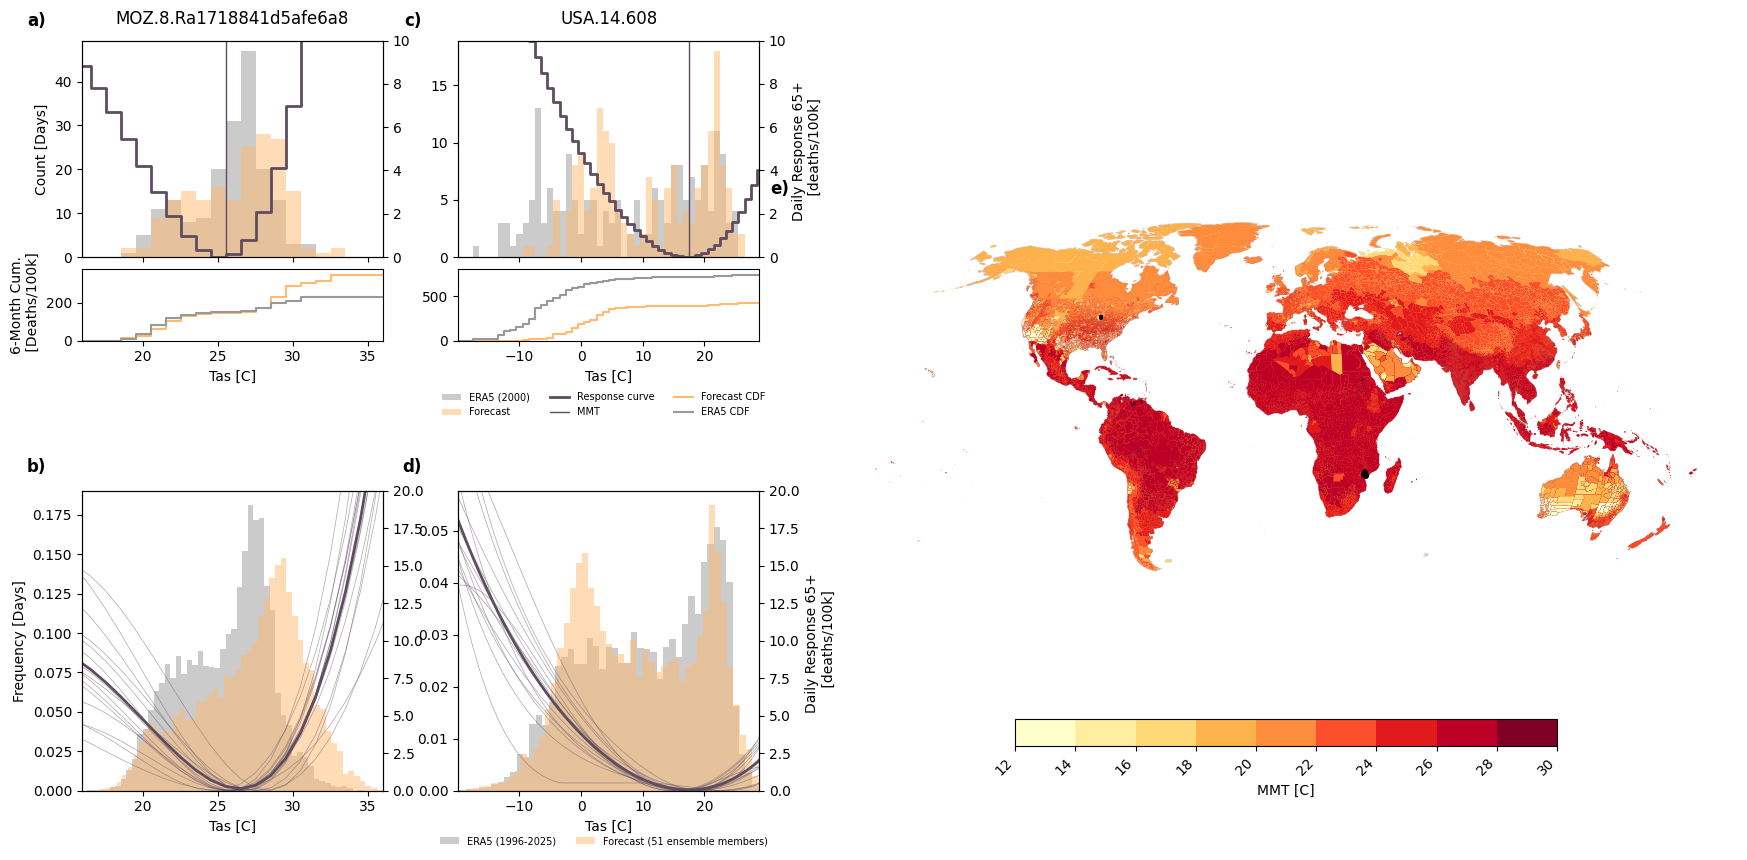

In [19]:
fig = plt.figure(figsize=(18, 12), constrained_layout=False)
gs_top = fig.add_gridspec(1, 3, width_ratios=[1, 1, 3], wspace=0.15)

region_ids = ["MOZ.8.Ra1718841d5afe6a8", "USA.14.608"] 
panel_labels = [("a)", "b)"), ("c)", "d)")]
axes_by_region = {}

handles_top, labels_top = None, None
handles_bottom, labels_bottom = None, None

for col, region_filter in enumerate(region_ids):
    gs_outer_padded = gs_top[col].subgridspec(3, 1, height_ratios=[0.1, 1, 0.1])
    gs_outer = gs_outer_padded[1].subgridspec(2, 1, height_ratios=[1, 1], hspace=0.5)
    gs_inner = gs_outer[0].subgridspec(2, 1, height_ratios=[3, 1], hspace=0.08)

    ax_hist = fig.add_subplot(gs_inner[0])
    ax_cdf = fig.add_subplot(gs_inner[1], sharex=ax_hist)
    ax_hist.tick_params(labelbottom=False)

    ax = fig.add_subplot(gs_outer[1])
    ax_hist.text(
    -0.12, 1.05, panel_labels[col][0],
    transform=ax_hist.transAxes,
    fontsize=12, fontweight="bold", va="bottom", ha="right",
    )
    ax.text(
        -0.12, 1.05, panel_labels[col][1],
        transform=ax.transAxes,
        fontsize=12, fontweight="bold", va="bottom", ha="right",
    )


    axes_by_region[region_filter] = {"ax_hist": ax_hist, "ax_cdf": ax_cdf, "ax": ax}

    ### Load Climate Data ###
    forecast_slice = forecast_ir["tas"].sel(number=1)
    forecast_local = forecast_slice.sel(region=region_filter)

    reanalysis_slice = era5_ir["tas"].sel(time=slice("2000-01-01", "2000-12-31"))
    month_mask = reanalysis_slice.month.isin(months).compute()
    reanalysis_slice = reanalysis_slice.where(month_mask, drop=True)
    reanalysis_local = reanalysis_slice.sel(region=region_filter)

    combined = np.concat(
        [forecast_local.values.flatten(), reanalysis_local.values.flatten()]
    )
    xmin, xmax = np.percentile(combined, [0, 100])
    xmin = xmin-3
    xmax = xmax+3

    cdf_data, max_cdf = diagnostic_utils.compute_cumulative_effect(
        forecast_slice, reanalysis_slice, region_filter, months, hotonly=hotonly
    )

    ## Top Plot: Single Histogram and CDF for each region
    b_color = "#999999"
    f_color = "#ffbb6f"
    r_color = "#5e4c5f"

    ref_vals = betas_mmt["mmt"].sel(region=region_filter).sel(age_cohort="age65plus")
    betas = betas_mmt["beta_hotonly"] if hotonly else betas_mmt["beta"]
    betas = betas.sel(sample=7)
    ref_vals = ref_vals.sel(sample=7)
    da_temp_bins = betas.sel(region=region_filter).sel(age_cohort="age65plus")
    da_temp_bins["tas_bin"] = da_temp_bins["tas_bin"]

    bins = da_temp_bins.coords["tas_bin"]
    ax_hist.hist(
        reanalysis_local.values.flatten(),
        bins=bins,
        alpha=0.5,
        label="ERA5 (2000)",
        density=density_hist,
        color=b_color,
    )
    ax_hist.hist(
        forecast_local.values.flatten(),
        bins=bins,
        alpha=0.5,
        label="Forecast",
        density=density_hist,
        color=f_color,
    )
    ax_hist.set_xlim(xmin, xmax)
    ax_hist.set_title(f"{region_filter}", pad=12)

    ax_hist2 = ax_hist.twinx()
    ax_hist2.step(
        da_temp_bins.coords["tas_bin"],
        da_temp_bins.values,
        where="pre",
        color=r_color,
        linewidth=2,
        label="Response curve",
    )
    ax_hist2.axvline(ref_vals.values, color=r_color, linewidth=1, label="MMT")
    ax_hist2.set_ylim(0, 10)
    ax_hist2.set_xlim(xmin, xmax)

    era5_centers, era5_cdf, fc_centers, fc_cdf = cdf_data

    ax_cdf.set_ylim(0, max_cdf * 1.1)
    ax_cdf.set_xlim(xmin, xmax)
    ax_cdf.set_xlabel("Tas [C]")
    ax_cdf.step(fc_centers, fc_cdf, where="post", color=f_color, label="Forecast CDF")
    ax_cdf.step(era5_centers, era5_cdf, where="post", color=b_color, label="ERA5 CDF")

    if col == 0:
        handles_top = (
            ax_hist.get_legend_handles_labels()[0]
            + ax_hist2.get_legend_handles_labels()[0]
            + ax_cdf.get_legend_handles_labels()[0]
        )
        labels_top = (
            ax_hist.get_legend_handles_labels()[1]
            + ax_hist2.get_legend_handles_labels()[1]
            + ax_cdf.get_legend_handles_labels()[1]
        )

    ## Lower Plot
    betas = betas_mmt["beta_hotonly"] if hotonly else betas_mmt["beta"]
    da_temp_bins = betas.sel(region=region_filter).sel(age_cohort="age65plus")
    da_temp_bins["tas_bin"] = da_temp_bins["tas_bin"]

    forecast_full = forecast_ir["tas"].sel(region=region_filter)
    era5_full = era5_ir["tas"].sel(region=region_filter)

    bins = 50
    ax.hist(
        era5_full.values.flatten(),
        bins=bins,
        alpha=0.5,
        label="ERA5 (1996-2025)",
        density=True,
        color=b_color,
    )
    ax.hist(
        forecast_full.values.flatten(),
        bins=bins,
        alpha=0.5,
        label="Forecast (51 ensemble members)",
        density=True,
        color=f_color,
    )

    ax.set_xlim(xmin, xmax)
    ax.set_xlabel("Tas [C]")

    ax_bottom2 = ax.twinx()
    for sample in range(0, 15):
        ax_bottom2.plot(
            da_temp_bins.coords["tas_bin"],
            da_temp_bins.sel(sample=sample).values,
            color=r_color,
            linewidth=0.5,
            alpha = 0.5,
        )
# Mean response curve
    ax_bottom2.plot(
                da_temp_bins.coords["tas_bin"],
                da_temp_bins.mean(dim='sample').values,
                color=r_color,
                linewidth=2,
                label="Response curve",
            )
    ax_bottom2.set_ylim(0, 20)
    ax_bottom2.set_xlim(xmin, xmax)

    # Shared labels: only outer columns get labeled
    if col == 0:
        ax_hist.set_ylabel("Count [Days]")
        ax_cdf.set_ylabel("6-Month Cum.\n [Deaths/100k]")
        ax.set_ylabel("Frequency [Days]")

    if col == len(region_ids) - 1:
        ax_hist2.set_ylabel("Daily Response 65+ \n [deaths/100k]")
        ax_bottom2.set_ylabel("Daily Response 65+ \n [deaths/100k]")

    if col == 0:
        handles_bottom = ax.get_legend_handles_labels()[0]
        labels_bottom = ax.get_legend_handles_labels()[1]

# Two separate shared legends: one for the top block, one for the bottom block
pos_top = ax_cdf.get_position()
fig.legend(
    handles_top, labels_top,
    fontsize=7, loc="upper center",
    bbox_to_anchor=(0.35, pos_top.y0 - 0.02),
    ncol=3, frameon=False,
)

pos_bottom = ax.get_position()
fig.legend(
    handles_bottom, labels_bottom,
    fontsize=7, loc="upper center",
    bbox_to_anchor=(0.35, pos_bottom.y0 - 0.05),
    ncol=2, frameon=False,
)

# Middle single plot, vertically centered in column 3, bigger
gs_mid = gs_top[2].subgridspec(3, 1, height_ratios=[0.02, 1, 0.02])
ax_mid = fig.add_subplot(gs_mid[1])

ax_mid.text(
    -0.05, 1.02, "e)",
    transform=ax_mid.transAxes,
    fontsize=12, fontweight="bold", va="bottom", ha="right",
)

min_val = betas_mmt["beta"].min(dim="tas_bin")
is_min = betas_mmt["beta"] == min_val
central_tas_bin = betas_mmt["tas_bin"].where(is_min).median(dim="tas_bin", skipna=True)
_polygons_mmt = analysis_utils.xarray_to_gpd(
    central_tas_bin.mean(dim="sample"), _polygons
)
analysis_utils.plot_single(
    _polygons_mmt,
    col="tas_bin",
    cm="YlOrRd",
    n_colors=10,
    vmin=12,
    vmax=30,
    sup_title="",
    cbar_label="MMT [C]",
    cbar_location="bottom",
    ax=ax_mid,
)
_polygons_mmt[_polygons_mmt['region'].isin(region_ids)].plot(ax=ax_mid, facecolor='none', edgecolor='black', linewidth=2)

fig.subplots_adjust(top=0.93, bottom=0.08, left=0.06, right=0.98)

fig.savefig("fig1_method.png", dpi = 600, bbox_inches="tight")